In [1]:
from pathlib import Path
from PIL import Image
import numpy as np
import tensorflow as tf
import os

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
raw_model = "../models/antispoof_raw.keras"
transfer_model = "../models/antispoof_transfer.keras"

if not os.path.exists(raw_model):
    raise FileNotFoundError(f"Raw model not found at {raw_model}")
if not os.path.exists(transfer_model):
    raise FileNotFoundError(f"Transfer model not found at {transfer_model}")
else:
    print (f"Models found at {raw_model} and {transfer_model}")

Models found at ../models/antispoof_raw.keras and ../models/antispoof_transfer.keras


In [3]:
raw_model = tf.keras.models.load_model(raw_model)
transfer_model = tf.keras.models.load_model(transfer_model)
print("Raw model summary:")
raw_model.summary()
print("\nTransfer model summary:")
transfer_model.summary()

Raw model summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,669 (1.26 MB)

 Trainable params: 109,889 (429.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_8 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,944,133 (15.05 MB)

 Trainable params: 802,049 (3.06 MB)

 Non-trainable params: 1,537,984 (5.87 MB)

 Optimizer params: 1,604,100 (6.12 MB)

In [4]:
print(Path.cwd().parent.parent)

/Users/finnerty/Documents/Swinburne/FinalSem/MachineSystems/AMLFacialRecognitionProject


In [5]:
PROJECT_ROOT = Path.cwd().parent.parent

DATASET = (
    PROJECT_ROOT
    / "data"
    / "lcc-fasd-casia"
    / "LCC_FASD"
)

TEST_IMG_DIR = DATASET / "LCC_FASD_evaluation"

print(TEST_IMG_DIR)
print(TEST_IMG_DIR.exists())

/Users/finnerty/Documents/Swinburne/FinalSem/MachineSystems/AMLFacialRecognitionProject/data/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation
True


In [6]:
def load_eval_folder(folder, img_size=(224, 224)):
    X = []
    y = []

    class_map = {
        "real": 0,
        "spoof": 1
    }

    folder = Path(folder)

    for class_name, label in class_map.items():
        class_dir = folder / class_name

        print(f"Loading {class_name} from:", class_dir)

        files = []

        for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
            files.extend(class_dir.rglob(ext))

        print(f"{class_name} files found:", len(files))

        for path in files:
            try:
                img = Image.open(path).convert("RGB")
                img = img.resize(img_size)

                X.append(np.array(img))
                y.append(label)

            except Exception as e:
                print("Skipping:", path, e)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    return X, y

In [7]:
X_test, y_test = load_eval_folder(TEST_IMG_DIR)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Real count:", np.sum(y_test == 0))
print("Spoof count:", np.sum(y_test == 1))

Loading real from: /Users/finnerty/Documents/Swinburne/FinalSem/MachineSystems/AMLFacialRecognitionProject/data/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/real
real files found: 323
Loading spoof from: /Users/finnerty/Documents/Swinburne/FinalSem/MachineSystems/AMLFacialRecognitionProject/data/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof
spoof files found: 7312
X_test: (7635, 224, 224, 3)
y_test: (7635,)
Real count: 323
Spoof count: 7312


<h1>Anti-Spoof V1 (Raw)</h1>

In [8]:
loss, accuracy = raw_model.evaluate(
    X_test,
    y_test,
    batch_size=32,
    verbose=1
)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

239/239 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.7894 - loss: 0.5167
Test Accuracy: 0.7893909811973572
Test Loss: 0.5166592001914978


In [9]:
probs = raw_model.predict(
    X_test,
    batch_size=32,
    verbose=1
).flatten()

print(probs[:10])

239/239 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step
[0.01435588 0.26401898 0.9999697  0.43998227 0.5204436  0.8664313
 0.6851615  0.00575977 0.02030984 0.02797409]


In [10]:
threshold = 0.6

y_pred = (probs >= threshold).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Real", "Spoof"]
))

              precision    recall  f1-score   support

        Real       0.12      0.80      0.21       323
       Spoof       0.99      0.74      0.85      7312

    accuracy                           0.74      7635
   macro avg       0.55      0.77      0.53      7635
weighted avg       0.95      0.74      0.82      7635



In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 260   63]
 [1890 5422]]


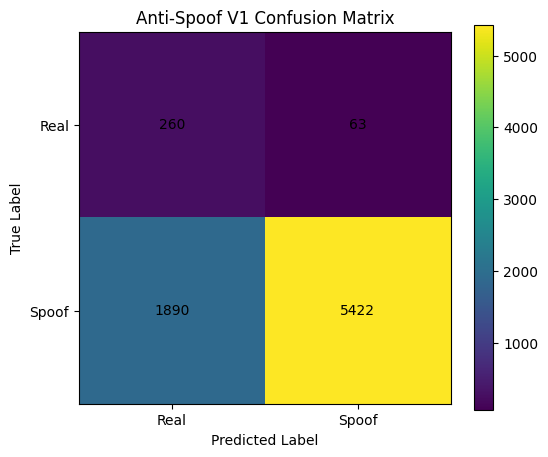

In [12]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.title("Anti-Spoof V1 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Real", "Spoof"])
plt.yticks([0, 1], ["Real", "Spoof"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

<h1>Anti-Spoof V2 (Transfer / Fine Tuning)</h1>

In [13]:
loss, accuracy = transfer_model.evaluate(
    X_test,
    y_test,
    batch_size=32,
    verbose=1
)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

239/239 ━━━━━━━━━━━━━━━━━━━━ 34s 131ms/step - accuracy: 0.8393 - loss: 0.7362
Test Accuracy: 0.8392927050590515
Test Loss: 0.7362488508224487


In [17]:
threshold = 0.6

y_pred = (probs >= threshold).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Real", "Spoof"]
))

              precision    recall  f1-score   support

        Real       0.18      0.83      0.29       323
       Spoof       0.99      0.83      0.90      7312

    accuracy                           0.83      7635
   macro avg       0.58      0.83      0.60      7635
weighted avg       0.96      0.83      0.88      7635



In [18]:
threshold = 0.6

y_pred = (probs >= threshold).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Real", "Spoof"]
))

              precision    recall  f1-score   support

        Real       0.18      0.83      0.29       323
       Spoof       0.99      0.83      0.90      7312

    accuracy                           0.83      7635
   macro avg       0.58      0.83      0.60      7635
weighted avg       0.96      0.83      0.88      7635



In [19]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 267   56]
 [1243 6069]]


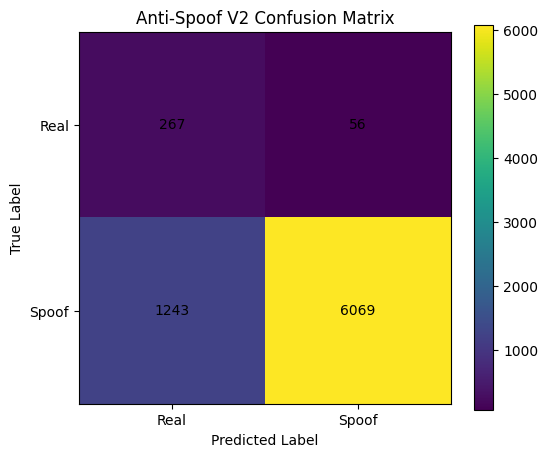

In [21]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.title("Anti-Spoof V2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Real", "Spoof"])
plt.yticks([0, 1], ["Real", "Spoof"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()